# Контекстное понимание сленга и хэштегов в социальных сетях малыми LLM для улучшения анонимизации

Студент: Стрельницкая Татьяна Викторовна, гр. J4240
Направление подготовки: 09.04.04 Программная инженерия


In [77]:
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from typing import List, Dict

from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import os
from sklearn.manifold import TSNE
import spacy
from tqdm import tqdm

sns.set(style="whitegrid")
torch.set_grad_enabled(False)

device = "cuda" if torch.cuda.is_available() else "cpu"

nlp = spacy.load("en_core_web_md")

In [78]:
df = pd.read_json("corpus.json", lines=True, encoding="utf-8")

df['target'].value_counts()

target
dope         150
crazy        150
slay         150
flex         150
vibe         150
lit          150
basic        150
swag         150
diss         150
cringe       150
fortnight    150
Name: count, dtype: int64

In [79]:
df.head()

,text,target
0,That beat is dope honestly,dope
1,Dope energy from the crowd tonight,dope
2,This jacket looks dope on you,dope
3,Low effort idea but somehow dope,dope
4,That transition was dope as hell,dope


In [ ]:
@dataclass
class ExperimentConfig:
    term: str
    embedding_type: str
    masked_model_name: str = "bert-base-uncased"

    auto_k: bool = True
    n_clusters: int = 2
    k_min: int = 1
    k_max: int = 5

    device: str = device
    n_examples_per_cluster: int = 5

In [81]:
def prepare_dataframe(texts: List[str], term: str) -> pd.DataFrame:
    rows = []
    for t in texts:
        if re.search(rf"\b{term}\b", t, re.IGNORECASE):
            masked = re.sub(rf"\b{term}\b", "[MASK]", t, flags=re.IGNORECASE)
            rows.append({
                "text": t,
                "anon_text": masked
            })
    return pd.DataFrame(rows)

In [82]:
def embed_masked(texts, tokenizer, model, device):
    model.to(device)
    model.eval()
    vectors = []

    for t in texts:
        inputs = tokenizer(t, return_tensors="pt").to(device)
        mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)

        with torch.no_grad():
            outputs = model(**inputs)

        if len(mask_idx[1]) == 0:
            vec = torch.zeros(model.config.hidden_size).numpy()
        else:
            vec = outputs.last_hidden_state[0, mask_idx[1], :].mean(dim=0).cpu().numpy()

        vectors.append(vec)

    return np.vstack(vectors)

sentence_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

def embed_sentence(texts):
    return sentence_model.encode(texts, show_progress_bar=False)

c:\Users\Таня\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [83]:
def find_best_k(X, k_min=1, k_max=5):
    best_k = k_min
    best_score = -1
    scores = {}

    max_k = min(k_max, len(X) - 1)

    for k in range(k_min, max_k + 1):
        if k == 1:
            score = 0.0
        else:
            labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
            score = silhouette_score(X, labels)

        scores[k] = score

        if score > best_score:
            best_score = score
            best_k = k

    if best_score < 0.1:
        best_k = 1
        best_score = 0.0

    return best_k, best_score, scores

In [84]:
def cluster_embeddings(X, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else 0
    return labels, sil, kmeans.cluster_centers_


def decode_centroid_masked_fast(centroid, tokenizer, model, device, top_k=10):
    model.to(device)
    model.eval()

    vocab_list = list(tokenizer.get_vocab().keys())[:1000]
    all_embeddings = []

    for w in vocab_list:
        text = f"[MASK] {w}"
        inputs = tokenizer(text, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)

        if len(mask_idx[1]) == 0:
            vec = torch.zeros(model.config.hidden_size).cpu().numpy()
        else:
            vec = outputs.last_hidden_state[0, mask_idx[1][0]].cpu().numpy()

        all_embeddings.append(vec)

    all_embeddings = np.vstack(all_embeddings)
    sims = cosine_similarity([centroid], all_embeddings)[0]
    top_idx = np.argsort(sims)[-top_k:][::-1]

    return [vocab_list[i] for i in top_idx]


def get_top_examples(texts, X_cluster, n=5):
    centroid = X_cluster.mean(axis=0)
    sims = cosine_similarity([centroid], X_cluster)[0]
    idx = np.argsort(sims)[-n:][::-1]
    return [texts[i] for i in idx]

In [85]:
def run_experiment(raw_texts, config, masked_tokenizer=None, masked_model=None, decode=False):
    df = prepare_dataframe(raw_texts, config.term)
    if len(df) < config.k_min:
        return []

    if config.embedding_type == "masked":
        X = embed_masked(df["anon_text"].tolist(), masked_tokenizer, masked_model, config.device)
    else:
        X = embed_sentence(df["text"].tolist())

    if config.auto_k:
        best_k, sil, sil_scores = find_best_k(X, config.k_min, config.k_max)
    else:
        best_k = config.n_clusters
        sil_scores = None

    labels, sil, centroids = cluster_embeddings(X, best_k)

    cluster_results = []

    for c in range(best_k):
        idx = np.where(labels == c)[0]

        if len(idx) == 0:
            continue

        if decode and config.embedding_type == "masked":
            decoded = decode_centroid_masked_fast(
                centroids[c],
                masked_tokenizer,
                masked_model,
                config.device
            )
            examples = get_top_examples(df["anon_text"].tolist(), X[idx], config.n_examples_per_cluster)
        else:
            decoded = None
            examples = get_top_examples(df["text"].tolist(), X[idx], config.n_examples_per_cluster)

        cluster_results.append({
            "cluster": c,
            "n_contexts": len(idx),
            "silhouette": sil,
            "best_k": best_k,
            "silhouette_k": sil_scores,
            "decoded_lemmas": decoded,
            "examples": examples
        })

    return cluster_results

In [86]:
def experiment_quality_vs_N(raw_texts, term, embedding_type, Ns, masked_tokenizer=None, masked_model=None):
    rows = []

    for N in tqdm(Ns, desc=f"{term} | {embedding_type}"):
        subset = raw_texts[:N]

        config = ExperimentConfig(
            term=term,
            embedding_type=embedding_type
        )

        clusters = run_experiment(subset, config, masked_tokenizer, masked_model, decode=False)

        for cl in clusters:
            rows.append({
                "term": term,
                "N": N,
                "embedding": embedding_type,
                "cluster": cl["cluster"],
                "n_contexts": cl["n_contexts"],
                "silhouette": cl["silhouette"],
                "best_k": cl["best_k"],
                "silhouette_k": cl["silhouette_k"],
                "decoded_lemmas": cl["decoded_lemmas"],
                "examples": cl["examples"]
            })

    return pd.DataFrame(rows)

In [87]:
masked_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
masked_model = AutoModel.from_pretrained("bert-base-uncased")

targets = ["dope", "crazy", "slay", "flex", "vibe", "lit",
           "basic", "swag", "diss", "cringe", "fortnight"]

Ns = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]

all_results = []

In [88]:
for term in tqdm(targets, desc="Terms"):
    raw_texts = df[df['target'] == term]['text'].tolist()

    print(f"Running experiments for '{term}'")

    df_masked = experiment_quality_vs_N(
        raw_texts,
        term,
        "masked",
        Ns,
        masked_tokenizer,
        masked_model
    )

    all_results.append(df_masked)

df_results = pd.concat(all_results, ignore_index=True)
df_results.to_csv("experiment_results_1.csv", index=False)

Terms:   0%|          | 0/11 [00:00<?, ?it/s]

Running experiments for 'dope'


dope | masked: 100%|██████████| 16/16 [00:37<00:00,  2.32s/it]
Terms:   9%|▉         | 1/11 [00:37<06:12, 37.28s/it]

Running experiments for 'crazy'


crazy | masked: 100%|██████████| 16/16 [00:38<00:00,  2.39s/it]
Terms:  18%|█▊        | 2/11 [01:15<05:41, 37.89s/it]

...

diss | masked: 100%|██████████| 16/16 [00:26<00:00,  1.67s/it]
Terms:  82%|████████▏ | 9/11 [04:48<00:58, 29.49s/it]

Running experiments for 'cringe'


cringe | masked: 100%|██████████| 16/16 [00:31<00:00,  1.95s/it]
Terms:  91%|█████████ | 10/11 [05:19<00:30, 30.01s/it]

Running experiments for 'fortnight'


fortnight | masked: 100%|██████████| 16/16 [00:26<00:00,  1.64s/it]
Terms: 100%|██████████| 11/11 [05:45<00:00, 31.44s/it]


In [89]:
df_results

,term,N,embedding,cluster,n_contexts,silhouette,best_k,silhouette_k,decoded_lemmas,examples
0,dope,5,masked,0,5,0.000000,1,"{1: 0.0, 2: 0.08907792717218399, 3: 0.08064483...",None,"[That beat is dope honestly, That transition w..."
1,dope,10,masked,0,1,0.125133,2,"{1: 0.0, 2: 0.1251334547996521, 3: 0.062085025...",None,[That beat is dope honestly]
2,dope,10,masked,1,9,0.125133,2,"{1: 0.0, 2: 0.1251334547996521, 3: 0.062085025...",None,"[That beat is dope honestly, Simple concept, d..."
3,dope,20,masked,0,15,0.205115,2,"{1: 0.0, 2: 0.20511464774608612, 3: 0.13829679...",None,"[That beat is dope honestly, Unexpectedly dope..."
4,dope,20,masked,1,5,0.205115,2,"{1: 0.0, 2: 0.20511464774608612, 3: 0.13829679...",None,"[That transition was dope as hell, Low effort ..."
...,...,...,...,...,...,...,...,...,...,...
454,fortnight,140,masked,0,92,0.186759,2,"{1: 0.0, 2: 0.18675903975963593, 3: 0.16566029...",None,[Fortnight competition hype! Who’s joining the...
455,fortnight,140,masked,1,36,0.186759,2,"{1: 0.0, 2: 0.18675903975963593, 3: 0.16566029...",None,[Fortnight gaming updates make me obsessed 😅 #...
456,fortnight,150,masked,0,18,0.190367,3,"{1: 0.0, 2: 0.18655721843242645, 3: 0.19036708...",None,"[Road trip in a fortnight 🚗 adventure time!, N..."
457,fortnight,150,masked,1,28,0.190367,3,"{1: 0.0, 2: 0.18655721843242645, 3: 0.19036708...",None,[Can’t wait for the fortnight marathon of my f...


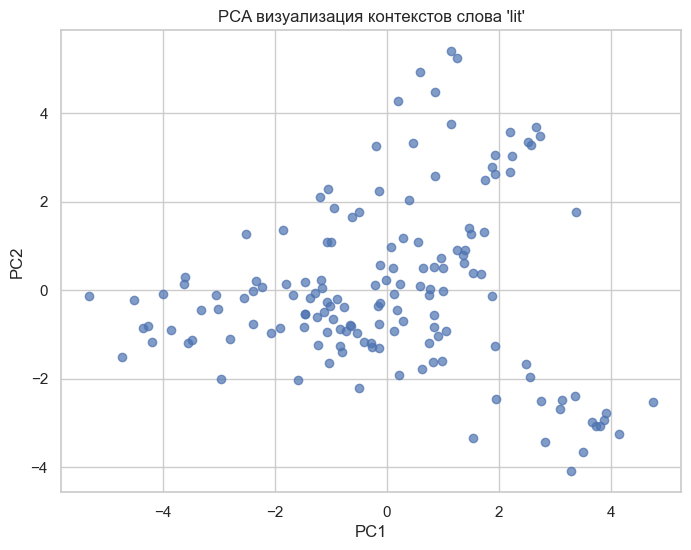

In [90]:
texts_lit = df[df['target'] == 'lit']['text'].tolist()

df_lit = prepare_dataframe(texts_lit, 'lit')
anon_texts = df_lit['anon_text'].tolist()

X_lit = embed_masked(anon_texts, masked_tokenizer, masked_model, device)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_lit)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.title("PCA визуализация контекстов слова 'lit'")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [91]:
os.makedirs("visualizations", exist_ok=True)

def visualize_word_contexts(term, X, n_clusters, texts=None):
    labels, sil, _ = cluster_embeddings(X, n_clusters=n_clusters)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(8,6))
    for i in range(n_clusters):
        plt.scatter(X_pca[labels==i,0], X_pca[labels==i,1], label=f'Cluster {i}', alpha=0.7)
    plt.title(f"PCA визуализация '{term}' с {n_clusters} кластерами")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"visualizations/PCA_{term}.png")
    plt.close()

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X)
    
    plt.figure(figsize=(8,6))
    for i in range(n_clusters):
        plt.scatter(X_tsne[labels==i,0], X_tsne[labels==i,1], label=f'Cluster {i}', alpha=0.7)
    plt.title(f"t-SNE визуализация '{term}' с {n_clusters} кластерами")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"visualizations/TSNE_{term}.png")
    plt.close()

In [92]:
for term in tqdm(targets):
    raw_texts = df[df['target'] == term]['text'].tolist()
    df_term = prepare_dataframe(raw_texts, term)
    anon_texts = df_term['anon_text'].tolist()
    X = embed_masked(anon_texts, masked_tokenizer, masked_model, device)

    best_k = df_results[(df_results['term']==term) & (df_results['N']==150)]['best_k'].iloc[0]
    visualize_word_contexts(term, X, n_clusters=best_k)

100%|██████████| 11/11 [00:47<00:00,  4.30s/it]


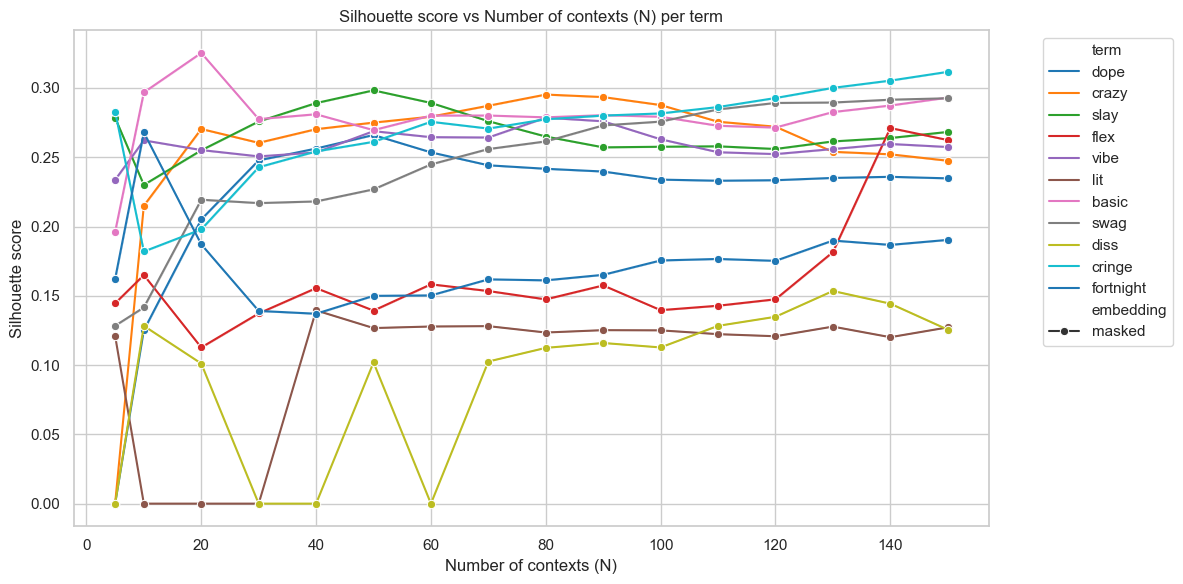

In [93]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_results,
    x="N",
    y="silhouette",
    hue="term",
    style="embedding",
    markers=True,
    dashes=False,
    palette="tab10"
)
plt.title("Silhouette score vs Number of contexts (N) per term")
plt.xlabel("Number of contexts (N)")
plt.ylabel("Silhouette score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

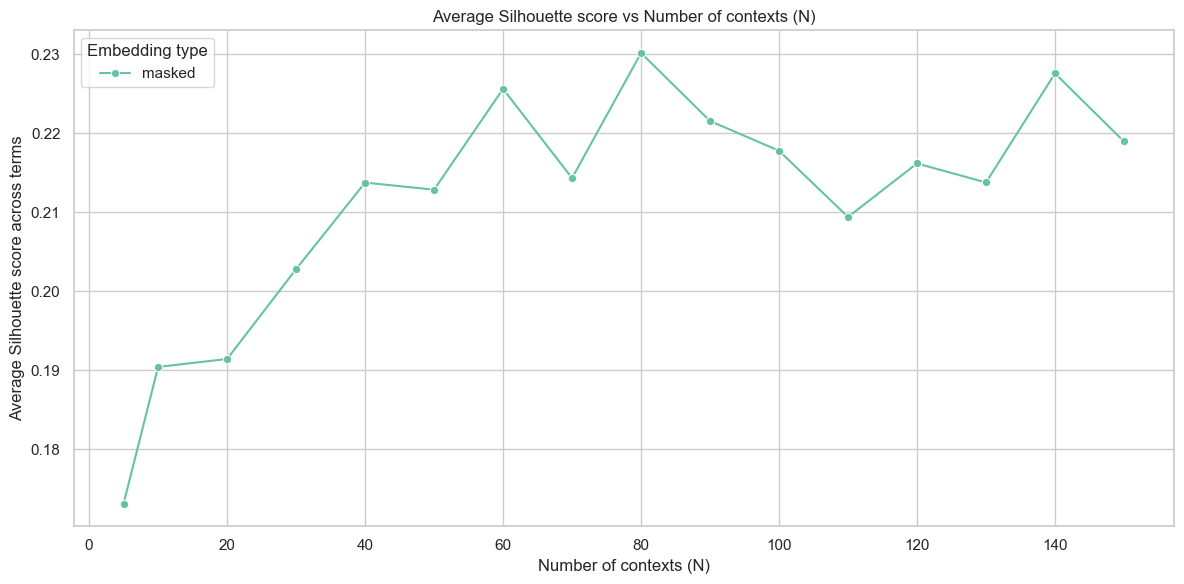

In [94]:
plt.figure(figsize=(12,6))
df_avg_sil = df_results.groupby(['N','embedding']).silhouette.mean().reset_index()

sns.lineplot(
    data=df_avg_sil,
    x="N",
    y="silhouette",
    hue="embedding",
    marker="o",
    palette="Set2"
)
plt.title("Average Silhouette score vs Number of contexts (N)")
plt.xlabel("Number of contexts (N)")
plt.ylabel("Average Silhouette score across terms")
plt.legend(title="Embedding type")
plt.tight_layout()
plt.show()

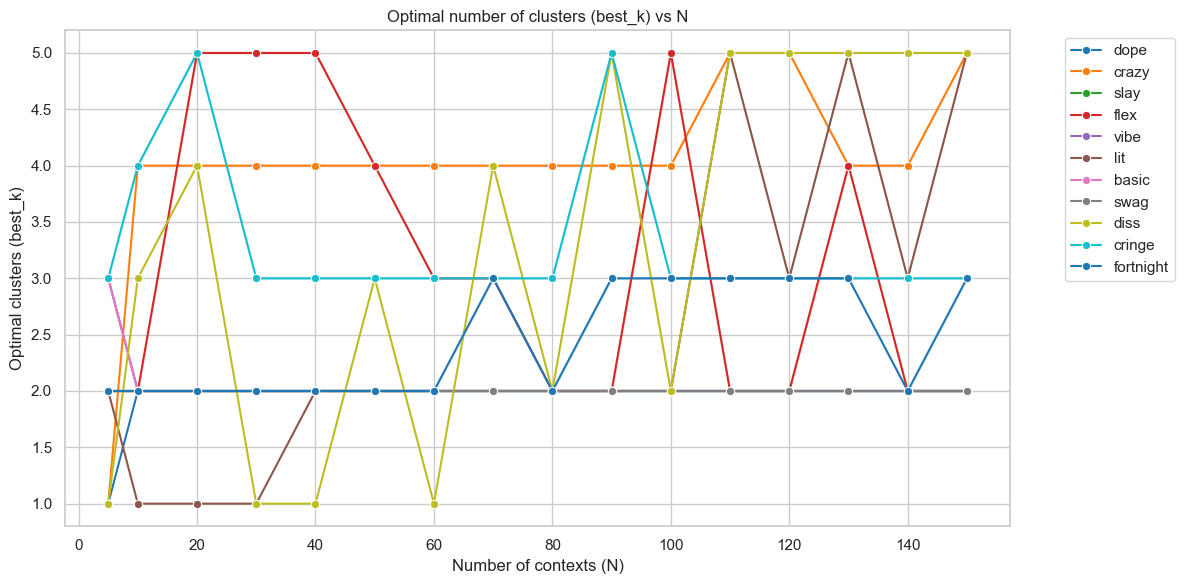

In [95]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_results,
    x="N",
    y="best_k",
    hue="term",
    marker="o",
    palette="tab10"
)
plt.title("Optimal number of clusters (best_k) vs N")
plt.xlabel("Number of contexts (N)")
plt.ylabel("Optimal clusters (best_k)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

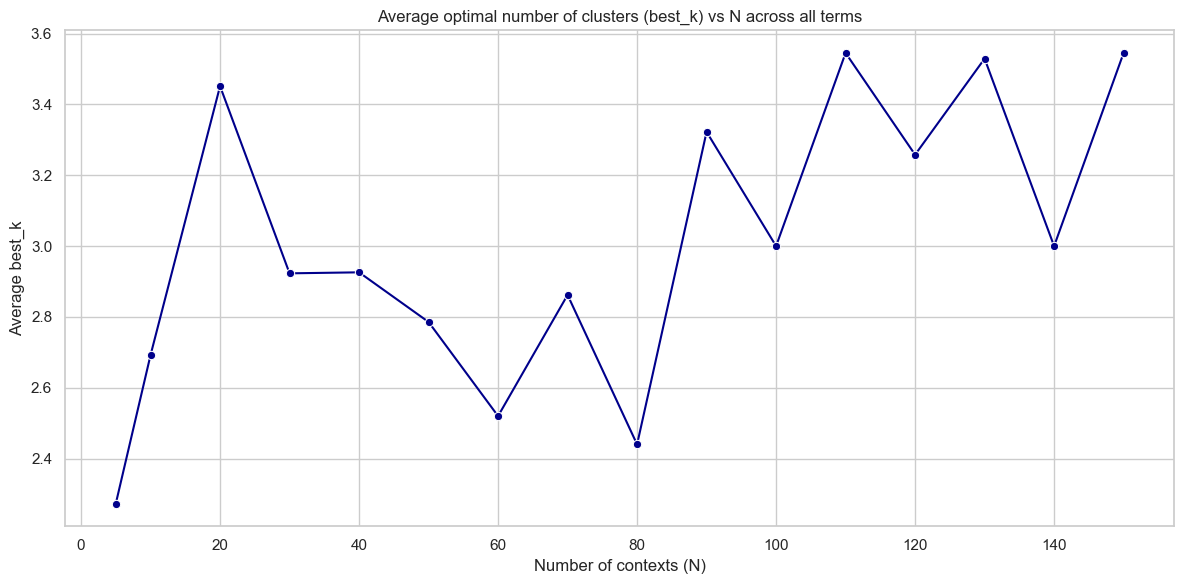

In [96]:
plt.figure(figsize=(12,6))
df_avg_k_all_terms = df_results.groupby('N').best_k.mean().reset_index()

sns.lineplot(
    data=df_avg_k_all_terms,
    x="N",
    y="best_k",
    marker="o",
    color="darkblue"
)
plt.title("Average optimal number of clusters (best_k) vs N across all terms")
plt.xlabel("Number of contexts (N)")
plt.ylabel("Average best_k")
plt.tight_layout()
plt.show()

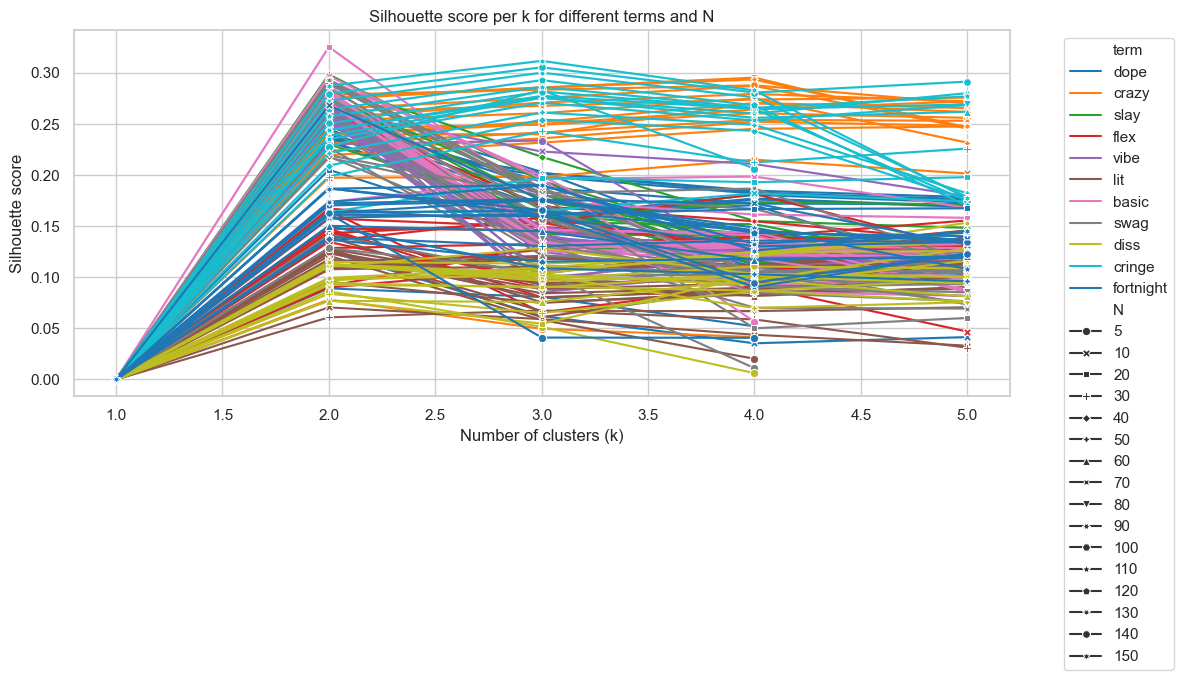

In [97]:
sil_k_df = []
for _, row in df_results.iterrows():
    if row['silhouette_k']:
        for k, score in row['silhouette_k'].items():
            sil_k_df.append({
                "term": row['term'],
                "N": row['N'],
                "k": k,
                "silhouette": score
            })

sil_k_df = pd.DataFrame(sil_k_df)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=sil_k_df,
    x="k",
    y="silhouette",
    hue="term",
    style="N",
    markers=True,
    dashes=False,
    palette="tab10"
)
plt.title("Silhouette score per k for different terms and N")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

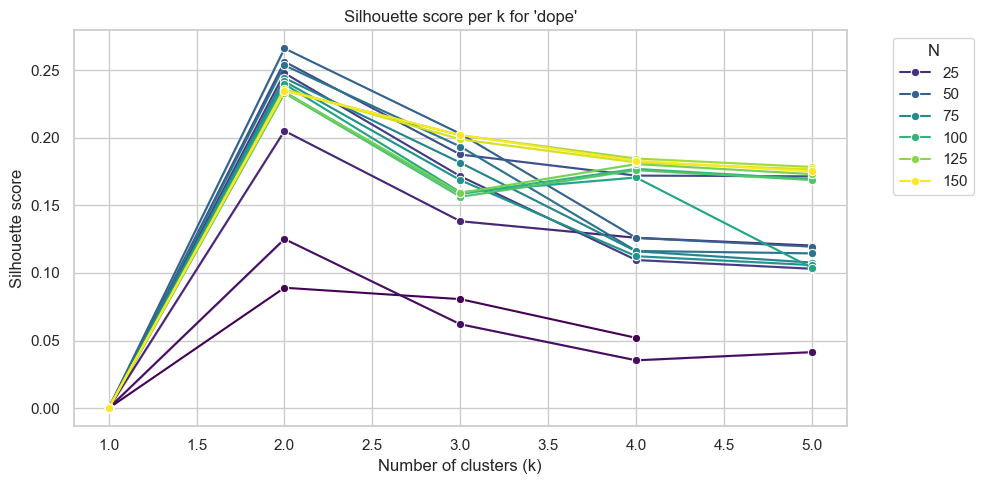

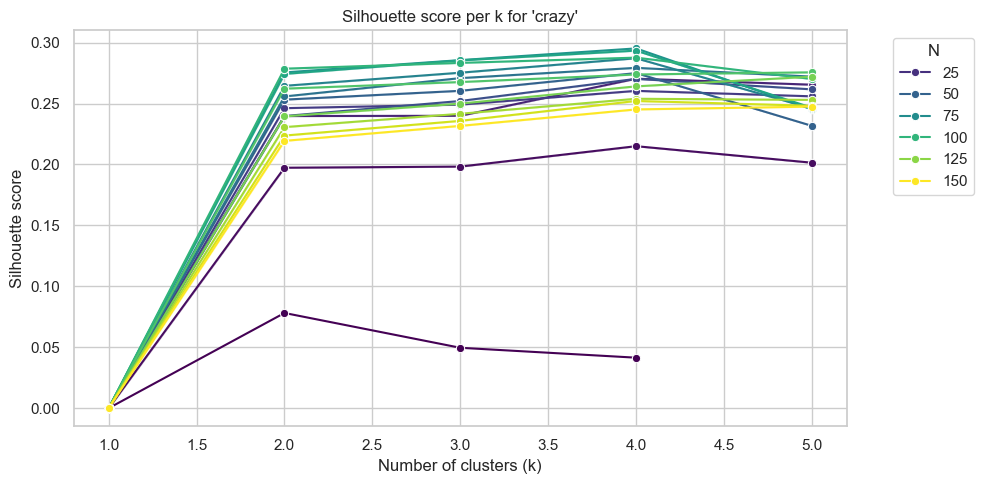

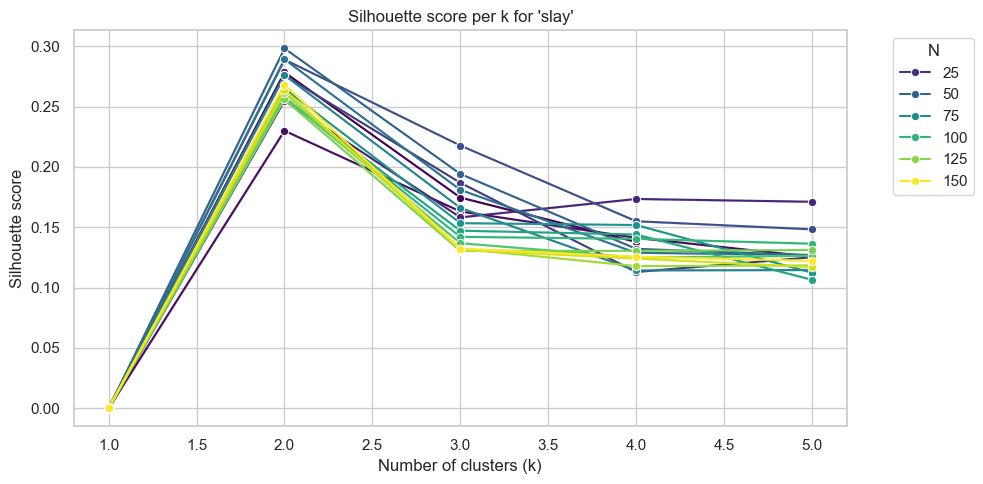

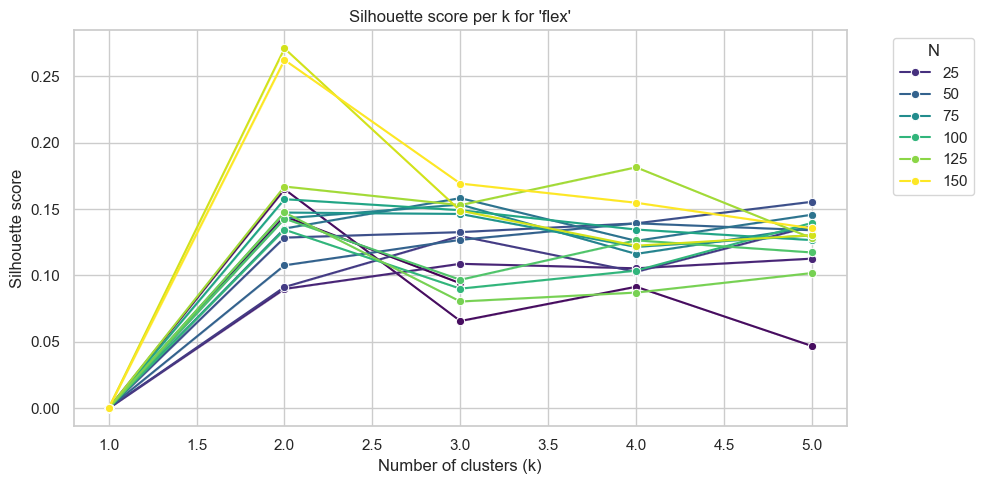

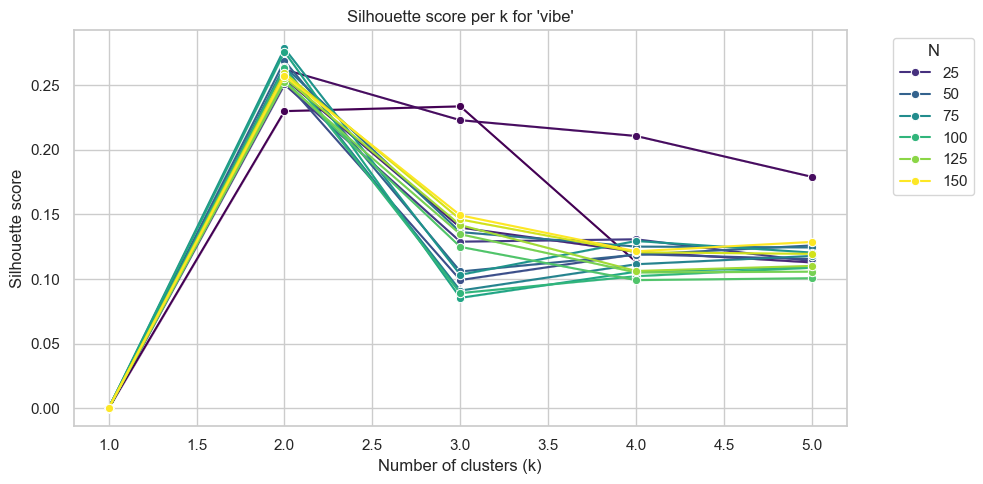

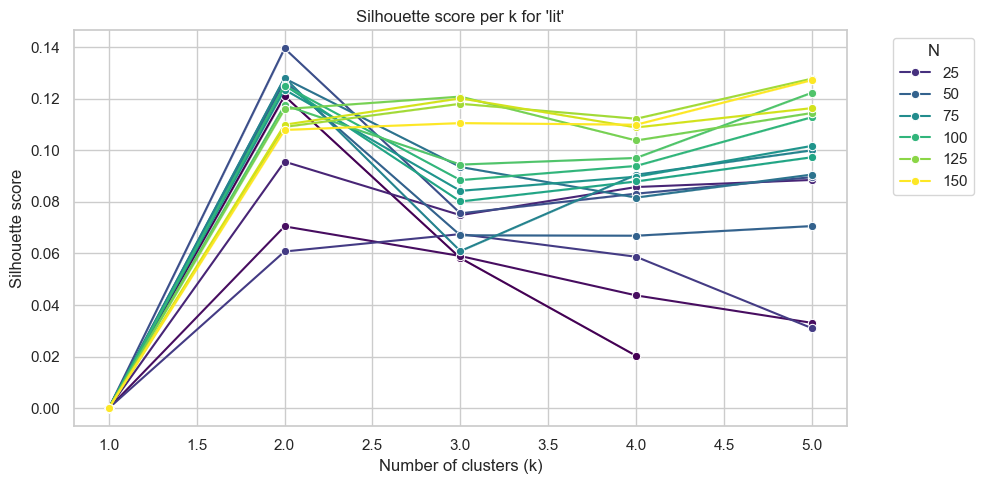

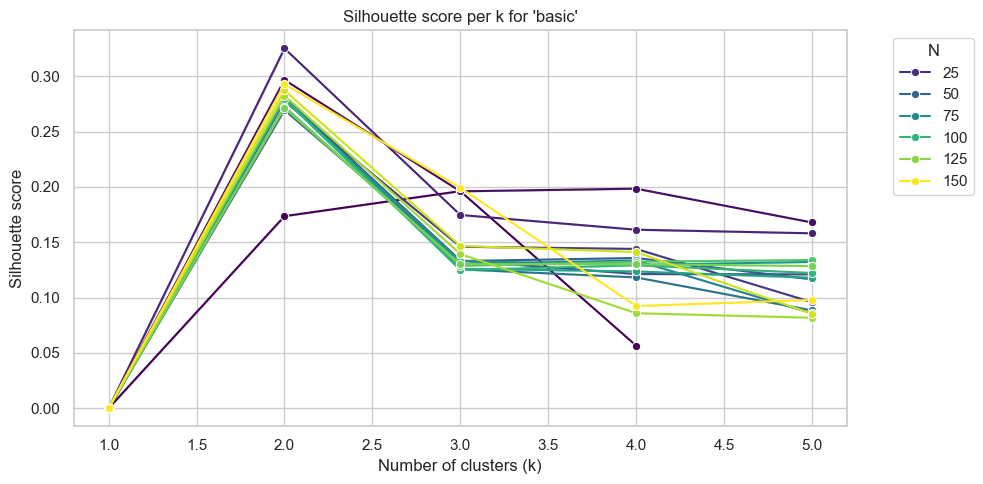

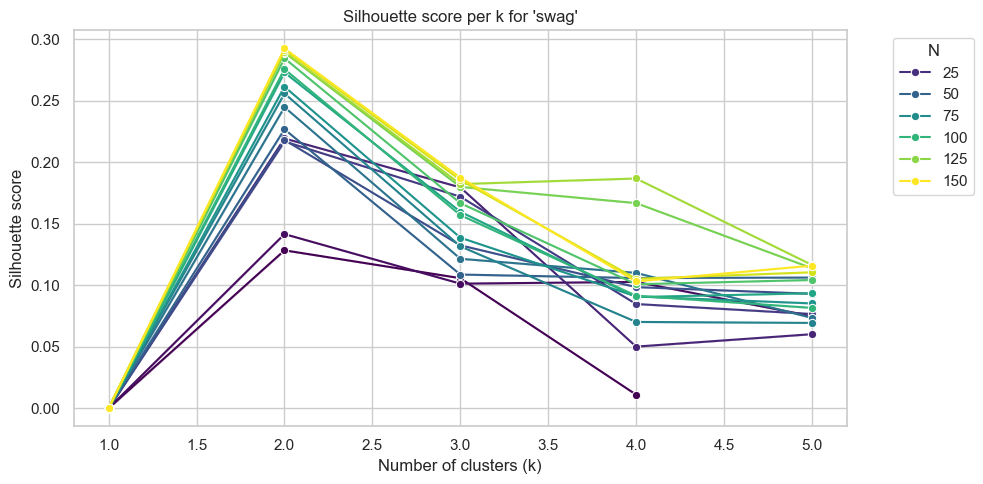

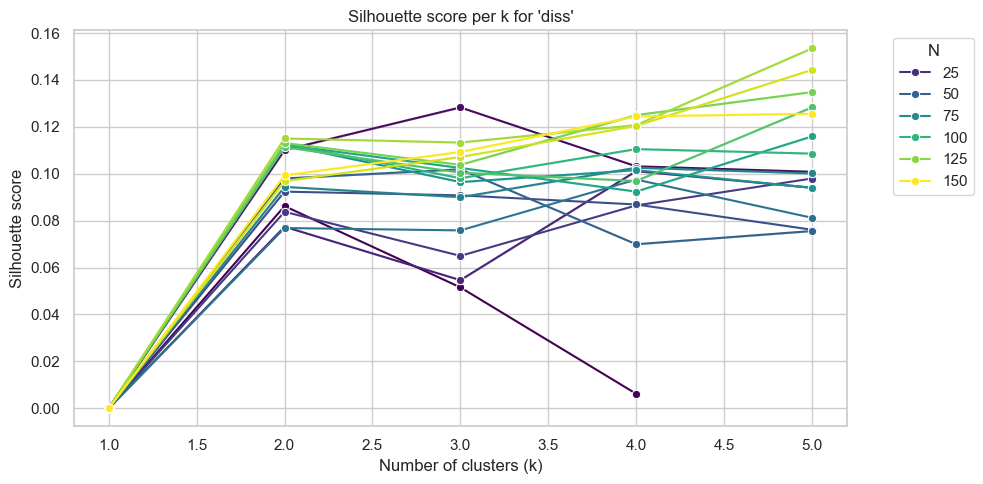

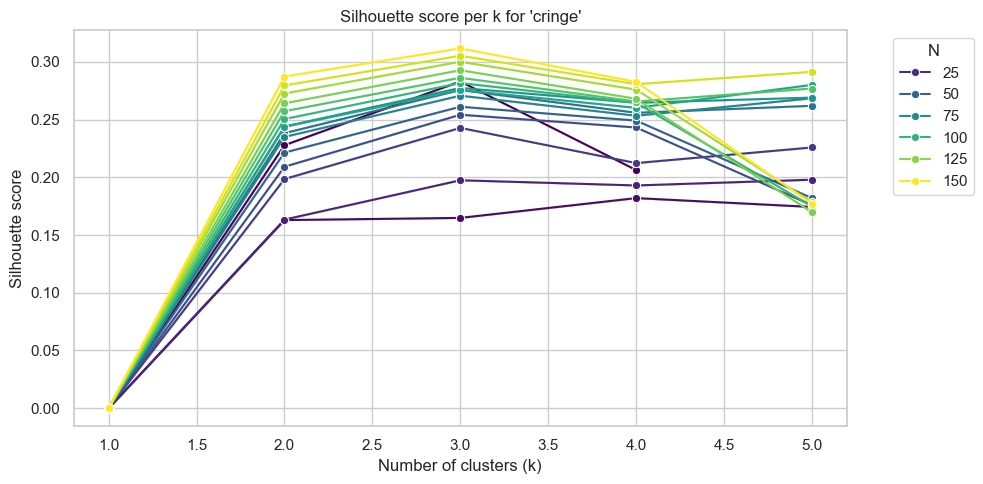

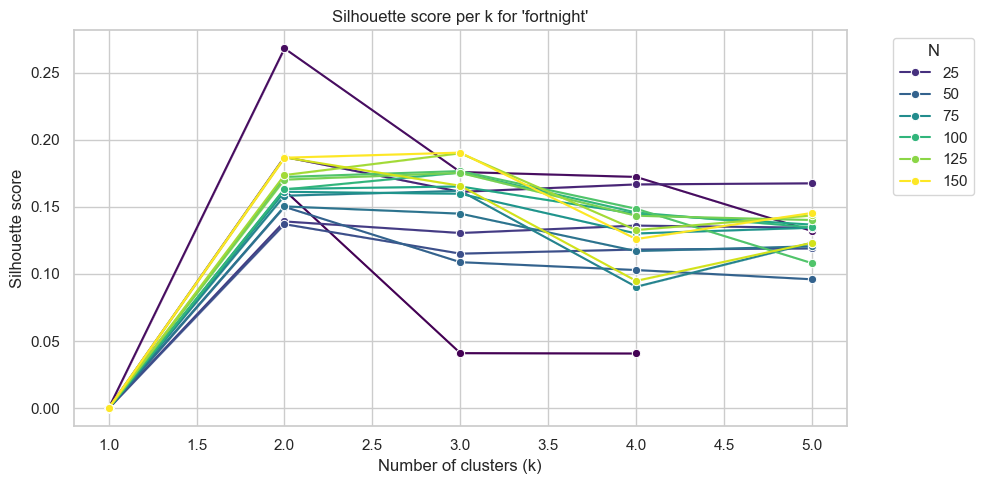

In [98]:
terms = df_results['term'].unique()

for term in terms:
    plt.figure(figsize=(10,5))
    df_term = sil_k_df[sil_k_df['term'] == term]
    sns.lineplot(
        data=df_term,
        x="k",
        y="silhouette",
        hue="N",
        marker="o",
        palette="viridis"
    )
    plt.title(f"Silhouette score per k for '{term}'")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette score")
    plt.legend(title="N", bbox_to_anchor=(1.05,1), loc="upper left")
    plt.tight_layout()
    plt.show()

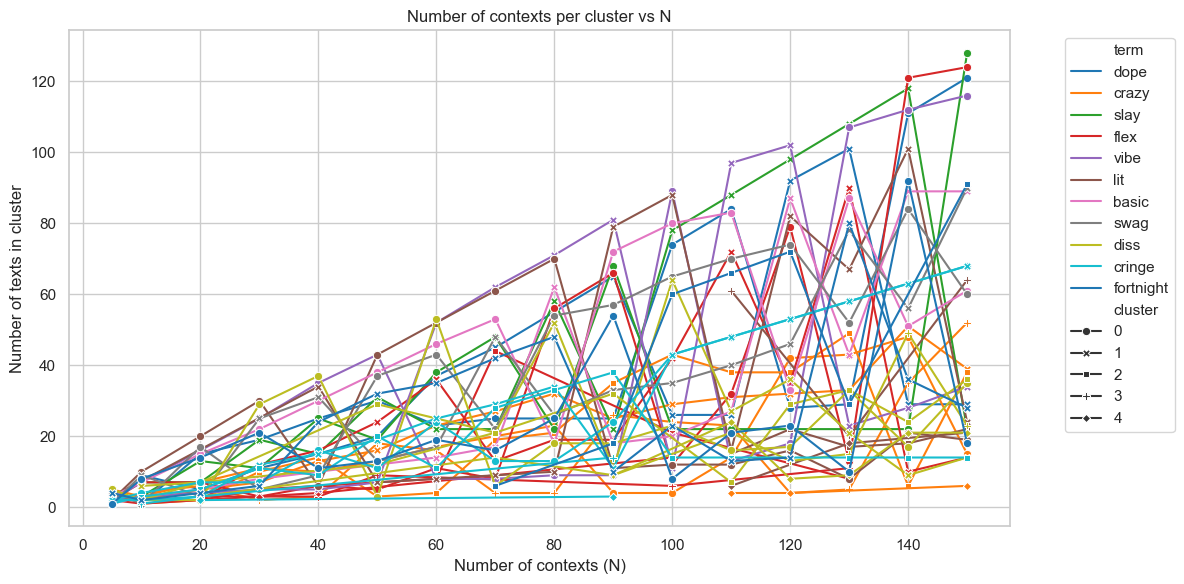

In [99]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_results,
    x="N",
    y="n_contexts",
    hue="term",
    style="cluster",
    markers=True,
    dashes=False,
    palette="tab10"
)
plt.title("Number of contexts per cluster vs N")
plt.xlabel("Number of contexts (N)")
plt.ylabel("Number of texts in cluster")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

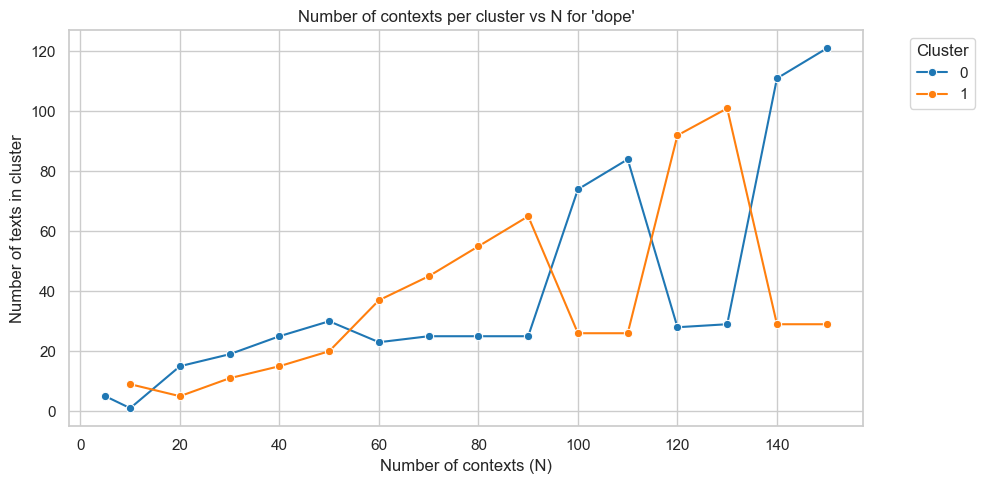

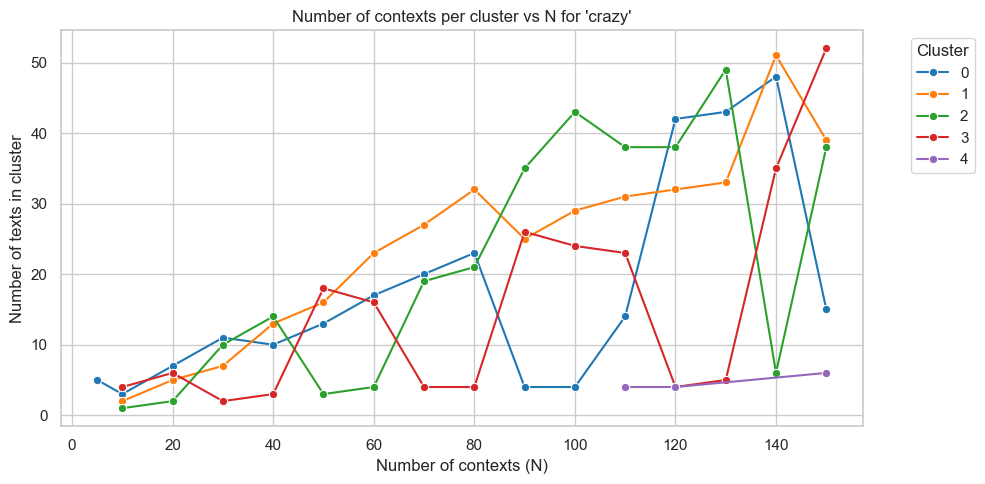

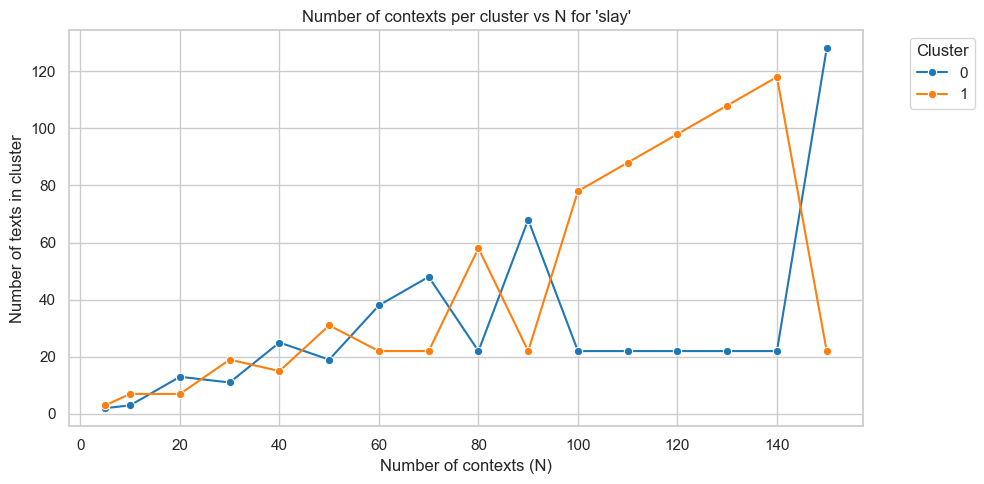

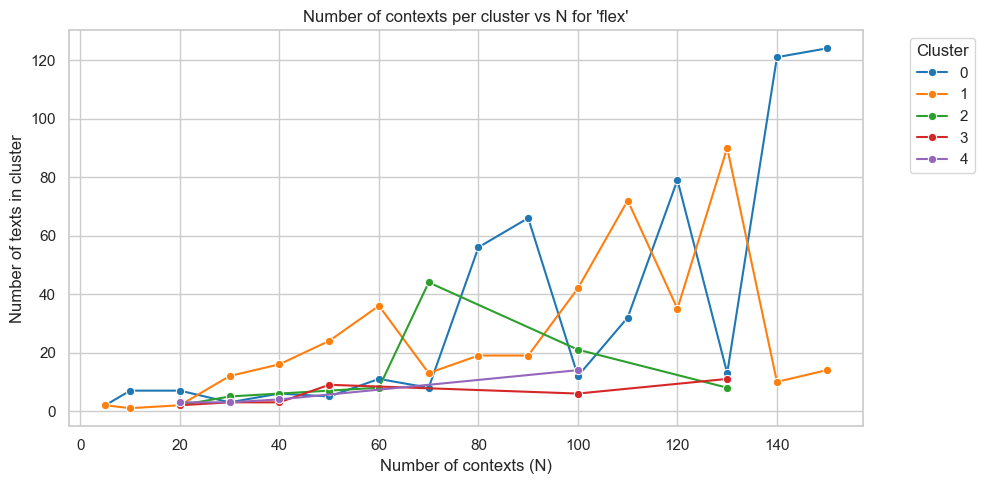

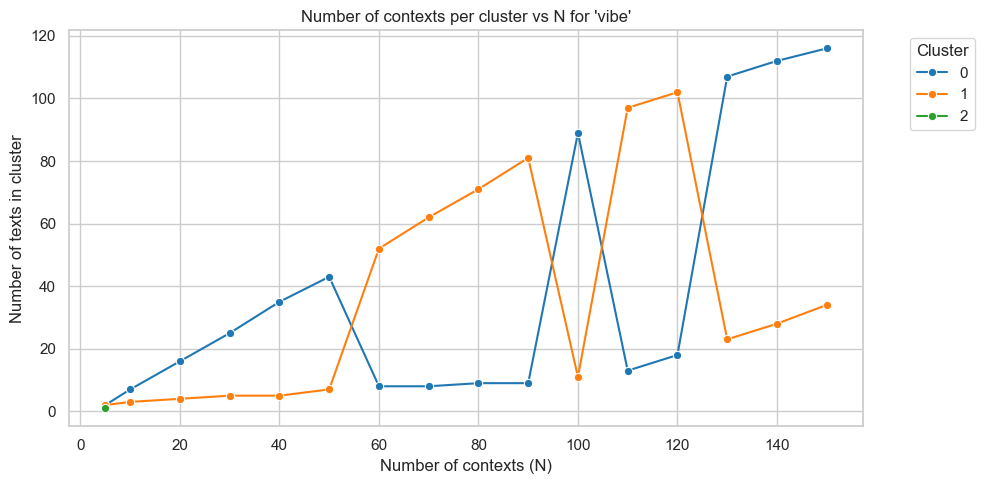

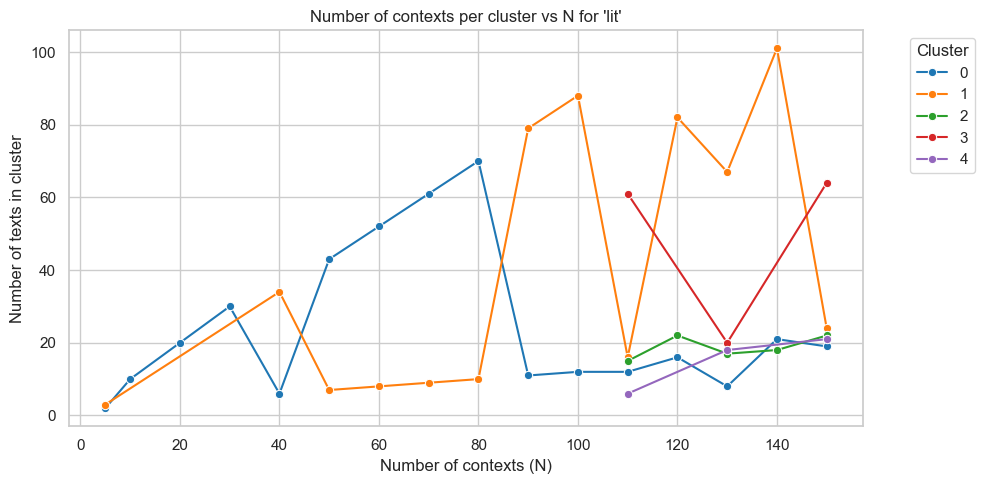

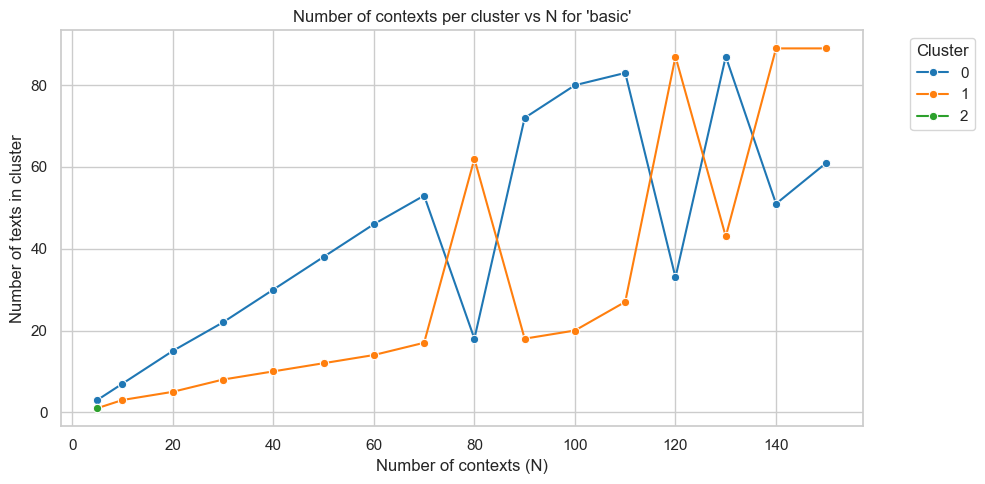

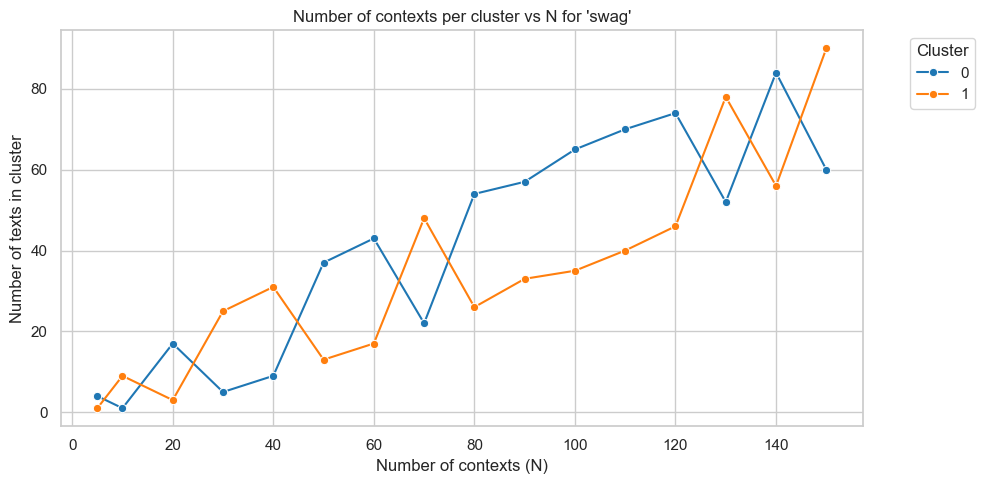

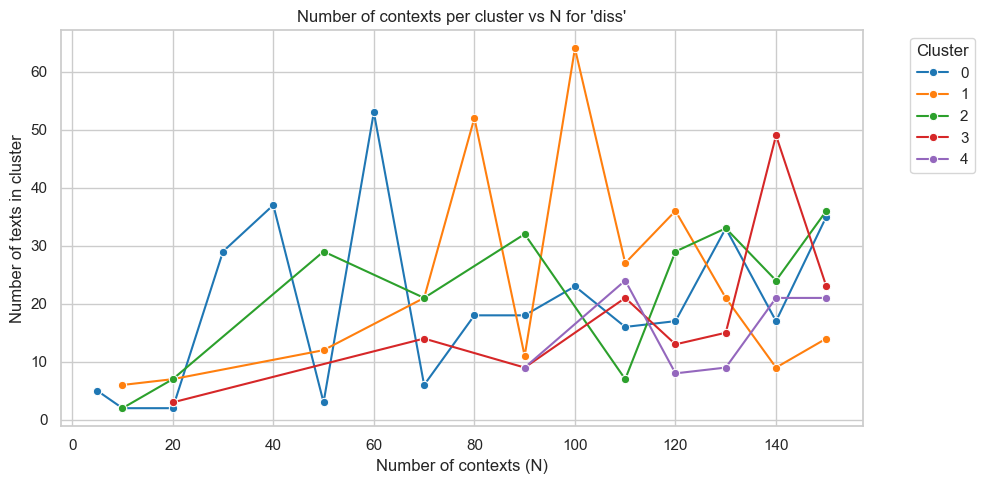

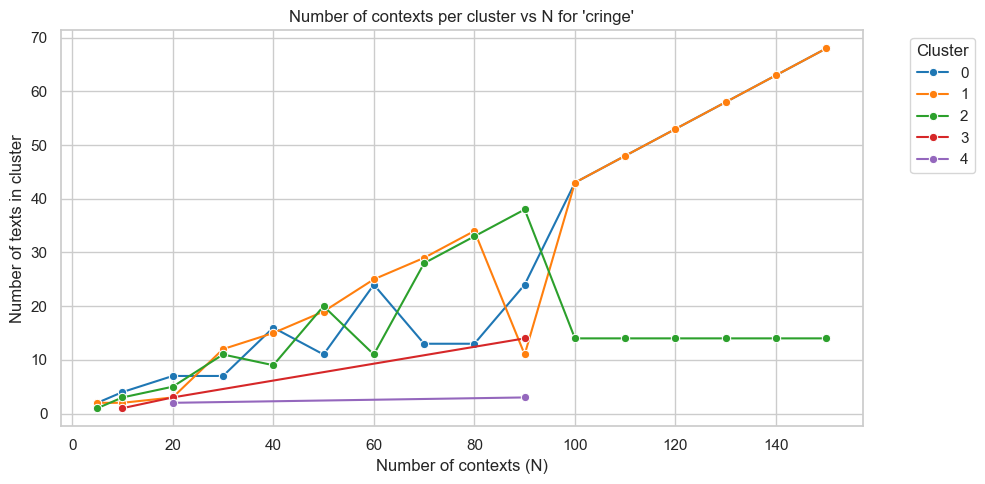

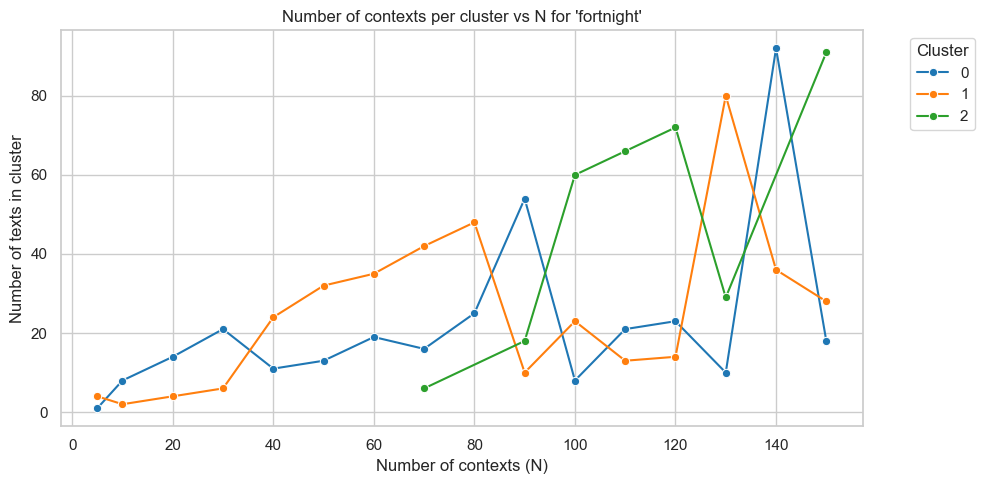

In [100]:
for term in terms:
    plt.figure(figsize=(10,5))
    df_term = df_results[df_results['term'] == term]
    sns.lineplot(
        data=df_term,
        x="N",
        y="n_contexts",
        hue="cluster",
        marker="o",
        palette="tab10"
    )
    plt.title(f"Number of contexts per cluster vs N for '{term}'")
    plt.xlabel("Number of contexts (N)")
    plt.ylabel("Number of texts in cluster")
    plt.legend(title="Cluster", bbox_to_anchor=(1.05,1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [101]:
for term in targets:
    df_term = df_results[(df_results['term'] == term) & (df_results['N'] == 150)]
    print(f"\nTerm: {term}")
    for idx, row in df_term.iterrows():
        print(f"Cluster {row['cluster']} ({row['n_contexts']} texts, Silhouette={row['silhouette']:.2f})")
        print("Decoded lemmas:", row['decoded_lemmas'])
        print("Examples:", row['examples'])
        print("-"*80)


Term: dope
Cluster 0 (121 texts, Silhouette=0.23)
Decoded lemmas: None
Examples: ['Dope flow carrying the whole track', 'Dope crowd engagement, everyone participating and feeling the energy together', 'Dope how the energy built gradually and peaked at the perfect moment', 'The DJ set was absolutely dope, everyone kept dancing nonstop', 'Dope atmosphere, perfect balance of excitement and chill vibes in the venue']
--------------------------------------------------------------------------------
Cluster 1 (29 texts, Silhouette=0.23)
Decoded lemmas: None
Examples: ['This whole setup is surprisingly dope', 'Dope flow but weak lyrics', 'Dope choice for an opening track', 'Dope colors mixed with minimal design', 'This remix sounds dope in headphones']
--------------------------------------------------------------------------------

Term: crazy
Cluster 0 (15 texts, Silhouette=0.25)
Decoded lemmas: None
Examples: ['Crazy vibes took over the audience, everyone started moving nonstop', 'The danc

In [102]:
final_N = 150
decoded_all = {}

for term in tqdm(targets, desc="Decoding terms"):
    raw_texts_term = df[df['target'] == term]['text'].tolist()
    
    best_k = df_results[
        (df_results['term'] == term) & 
        (df_results['N'] == final_N) & 
        (df_results['embedding'] == 'masked')
    ]['best_k'].iloc[0]

    config = ExperimentConfig(
        term=term,
        embedding_type="masked",
        auto_k=False,
        n_clusters=best_k,
        n_examples_per_cluster=5
    )

    clusters = run_experiment(
        raw_texts_term,
        config,
        masked_tokenizer,
        masked_model,
        decode=True
    )

    decoded_all[term] = clusters

Decoding terms: 100%|██████████| 11/11 [10:49<00:00, 59.07s/it]


In [103]:
decoded_all

{'dope': [{'cluster': 0,
   'n_contexts': 121,
   'silhouette': 0.23478993773460388,
   'best_k': 2,
   'silhouette_k': None,
   'decoded_lemmas': ['fascination',
    'gel',
    'grazing',
    'idea',
    'urges',
    'powerhouse',
    'word',
    'dressing',
    'truth',
    'bitterness'],
   'examples': ['[MASK] flow carrying the whole track',
    '[MASK] crowd engagement, everyone participating and feeling the energy together',
    '[MASK] how the energy built gradually and peaked at the perfect moment',
    'The DJ set was absolutely [MASK], everyone kept dancing nonstop',
    '[MASK] atmosphere, perfect balance of excitement and chill vibes in the venue']},
  {'cluster': 1,
   'n_contexts': 29,
   'silhouette': 0.23478993773460388,
   'best_k': 2,
   'silhouette_k': None,
   'decoded_lemmas': ['[CLS]',
    'facilitate',
    'however',
    '健',
    '」',
    'accumulate',
    'seeks',
    'sticking',
    'hash',
    'multiple'],
   'examples': ['This whole setup is surprisingly [MAS

# Дополнительные эксперименты

In [ ]:
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from typing import List, Dict

from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import spacy
from tqdm import tqdm

In [ ]:
@dataclass
class ExperimentConfig:
    term: str
    embedding_type: str 
    masked_model_name: str = "bert-base-uncased"
    n_clusters: int = 2
    device: str = device
    n_examples_per_cluster: int = 5

def prepare_dataframe(texts: List[str], term: str) -> pd.DataFrame:
    rows = []
    for t in texts:
        if re.search(rf"\b{term}\b", t, re.IGNORECASE):
            masked = re.sub(rf"\b{term}\b", "[MASK]", t, flags=re.IGNORECASE)
            rows.append({
                "text": t,
                "anon_text": masked
            })
    return pd.DataFrame(rows)

def embed_masked(texts, tokenizer, model, device):
    model.to(device)
    model.eval()
    vectors = []

    for t in texts:
        inputs = tokenizer(t, return_tensors="pt").to(device)
        mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)

        with torch.no_grad():
            outputs = model(**inputs)
        if len(mask_idx[1]) == 0:
            vec = torch.zeros(model.config.hidden_size).numpy()
        else:
            vec = outputs.last_hidden_state[0, mask_idx[1], :].mean(dim=0).cpu().numpy()
        vectors.append(vec)

    return np.vstack(vectors)

sentence_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
def embed_sentence(texts):
    return sentence_model.encode(texts, show_progress_bar=False)

def cluster_embeddings(X, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    sil = silhouette_score(X, labels) if len(np.unique(labels))>1 else 0
    return labels, sil, kmeans.cluster_centers_

def decode_centroid_masked_fast(centroid, tokenizer, model, device, top_k=10):

    model.to(device)
    model.eval()
    vocab_list = list(tokenizer.get_vocab().keys())[:1000]
    all_embeddings = []

    for w in tqdm(vocab_list, desc="Embedding vocab"):
        text = f"[MASK] {w}"
        inputs = tokenizer(text, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)
        if len(mask_idx[1]) == 0 or mask_idx[1][0] >= outputs.last_hidden_state.size(1):
            vec = torch.zeros(model.config.hidden_size).cpu().numpy()
        else:
            vec = outputs.last_hidden_state[0, mask_idx[1][0]].cpu().numpy()
        all_embeddings.append(vec)

    all_embeddings = np.vstack(all_embeddings)
    sims = cosine_similarity([centroid], all_embeddings)[0]
    top_idx = np.argsort(sims)[-top_k:][::-1]
    return [vocab_list[i] for i in top_idx]

def get_top_examples(texts, X_cluster, n=5):
    centroid = X_cluster.mean(axis=0)
    sims = cosine_similarity([centroid], X_cluster)[0]
    idx = np.argsort(sims)[-n:][::-1]
    return [texts[i] for i in idx]

def run_experiment(raw_texts, config, masked_tokenizer=None, masked_model=None):
    df = prepare_dataframe(raw_texts, config.term)
    if len(df) == 0:
        return None

    if config.embedding_type == "masked":
        X = embed_masked(df["anon_text"].tolist(), masked_tokenizer, masked_model, config.device)
    else:
        X = embed_sentence(df["text"].tolist())

    labels, sil, centroids = cluster_embeddings(X, config.n_clusters)

    cluster_results = []
    for c in range(config.n_clusters):
        idx_c = np.where(labels == c)[0]
        n_contexts = len(idx_c)
        if config.embedding_type == "masked":
            decoded = decode_centroid_masked_fast(
                centroids[c],
                masked_tokenizer,
                masked_model,
                device=config.device,
                top_k=10
            )
            examples = get_top_examples(df["anon_text"].tolist(), X[idx_c], n=config.n_examples_per_cluster)
        else:
            decoded = None
            examples = get_top_examples(df["text"].tolist(), X[idx_c], n=config.n_examples_per_cluster)

        cluster_results.append({
            "cluster": c,
            "n_contexts": n_contexts,
            "silhouette": sil,
            "decoded_lemmas": decoded,
            "examples": examples
        })

    return cluster_results

def experiment_quality_vs_N(raw_texts, term, embedding_type, Ns, masked_tokenizer=None, masked_model=None):
    results = []
    for N in Ns:
        subset = raw_texts[:N]
        config = ExperimentConfig(term=term, embedding_type=embedding_type)
        clusters = run_experiment(subset, config, masked_tokenizer, masked_model)
        for cl in clusters:
            results.append({
                "N": N,
                "embedding": embedding_type,
                "cluster": cl["cluster"],
                "n_contexts": cl["n_contexts"],
                "silhouette": cl["silhouette"],
                "decoded_lemmas": cl["decoded_lemmas"],
                "examples": cl["examples"]
            })
    return pd.DataFrame(results)

c:\Users\Таня\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
Ns = [20, 30, 50, 75, 100, 150]

masked_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
masked_model = AutoModel.from_pretrained("bert-base-uncased")

In [ ]:
df_masked = experiment_quality_vs_N(raw_texts, "lit", "masked", Ns, masked_tokenizer, masked_model)

Embedding vocab: 100%|██████████| 1000/1000 [00:18<00:00, 55.18it/s]


In [ ]:
df_sentence = experiment_quality_vs_N(raw_texts, "lit", "sentence", Ns)

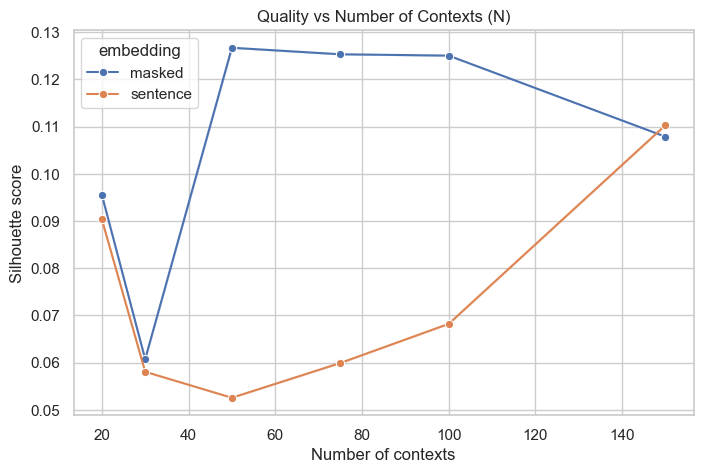

In [ ]:
df_results = pd.concat([df_masked, df_sentence], ignore_index=True)

plt.figure(figsize=(8,5))
sns.lineplot(data=df_results, x="N", y="silhouette", hue="embedding", marker="o")
plt.title("Quality vs Number of Contexts (N)")
plt.xlabel("Number of contexts")
plt.ylabel("Silhouette score")
plt.show()

In [15]:
df_results

,N,embedding,cluster,n_contexts,silhouette,decoded_lemmas,examples
0,20,masked,0,6,0.095573,"[drinking, welcoming, tonight, tricky, lass, m...","[That DJ set? Completely [MASK], crowd didn’t ..."
1,20,masked,1,14,0.095573,"[hazy, drinking, welcoming, framed, hysterical...",[The event was lowkey [MASK] despite the terri...
2,30,masked,0,16,0.060747,"[drinking, framed, hysterical, welcoming, chun...","[This bar gets [MASK] after midnight, trust me..."
3,30,masked,1,14,0.060747,"[welcoming, drinking, hazy, scents, marketplac...",[The event was lowkey [MASK] despite the terri...
4,50,masked,0,43,0.126722,"[drinking, welcoming, hazy, framed, hysterical...",[The vibe switched up and suddenly everything ...
5,50,masked,1,7,0.126722,"[drinking, tonight, welcoming, tricky, hazy, l...",[The vibe at that place last night was honestl...
6,75,masked,0,10,0.125339,"[drinking, tricky, welcoming, tonight, hazy, m...",[The energy in the room was [MASK] even before...
7,75,masked,1,65,0.125339,"[drinking, welcoming, hazy, framed, chunk, rai...","[That performance was surprisingly [MASK]., Th..."
8,100,masked,0,12,0.125059,"[drinking, tricky, welcoming, tonight, mug, ha...",[The energy in the room was [MASK] even before...
9,100,masked,1,88,0.125059,"[drinking, welcoming, hazy, framed, rainbow, m...","[That performance was surprisingly [MASK]., Th..."


In [ ]:
targets = ["dope", "crazy", "slay", "flex", "vibe", "lit", 
           "basic", "swag", "diss", "cringe", "fortnight"]

Ns = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]

all_results = []

for term in targets:
    raw_texts = df[df['target']==term]['text'].tolist()
    
    print(f"Running experiments for '{term}'...")

    df_masked = experiment_quality_vs_N(raw_texts, term, "masked", Ns, masked_tokenizer, masked_model)
    df_masked['embedding'] = 'masked'
 
    df_sentence = experiment_quality_vs_N(raw_texts, term, "sentence", Ns)
    df_sentence['embedding'] = 'sentence'
 
    df_masked['term'] = term
    df_sentence['term'] = term

    df_all = pd.concat([df_masked, df_sentence], ignore_index=True)
    all_results.append(df_all)

df_results = pd.concat(all_results, ignore_index=True)
df_results.to_csv("experiment_results.csv", index=False)

Running experiments for 'dope'...


Embedding vocab: 100%|██████████| 1000/1000 [00:17<00:00, 58.65it/s]


Running experiments for 'crazy'...


Embedding vocab: 100%|██████████| 1000/1000 [00:17<00:00, 58.12it/s]


Running experiments for 'slay'...


...

Embedding vocab: 100%|██████████| 1000/1000 [00:17<00:00, 58.79it/s]


Running experiments for 'cringe'...


Embedding vocab: 100%|██████████| 1000/1000 [00:16<00:00, 58.92it/s]


Running experiments for 'fortnight'...


Embedding vocab: 100%|██████████| 1000/1000 [00:16<00:00, 58.89it/s]


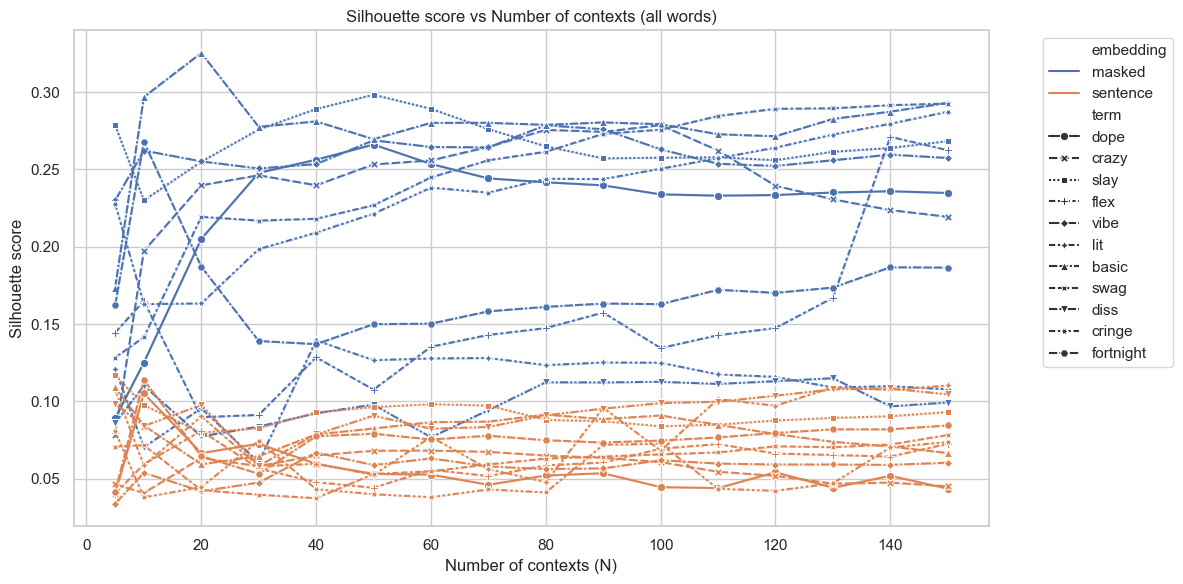

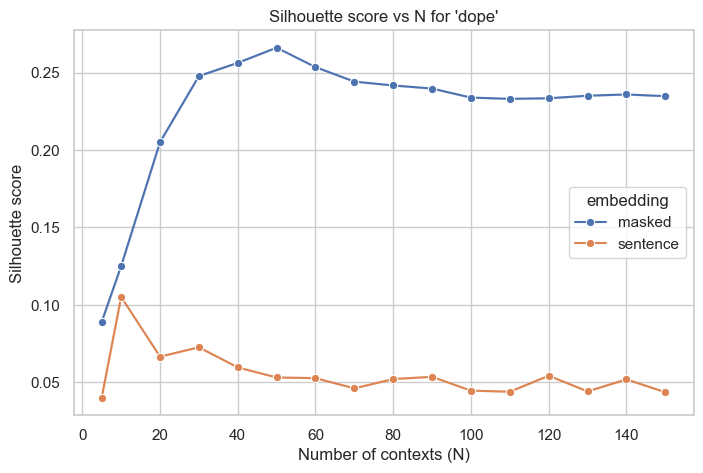

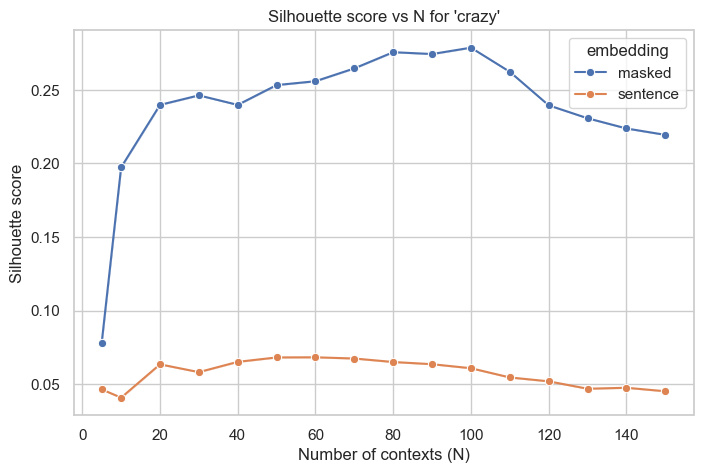

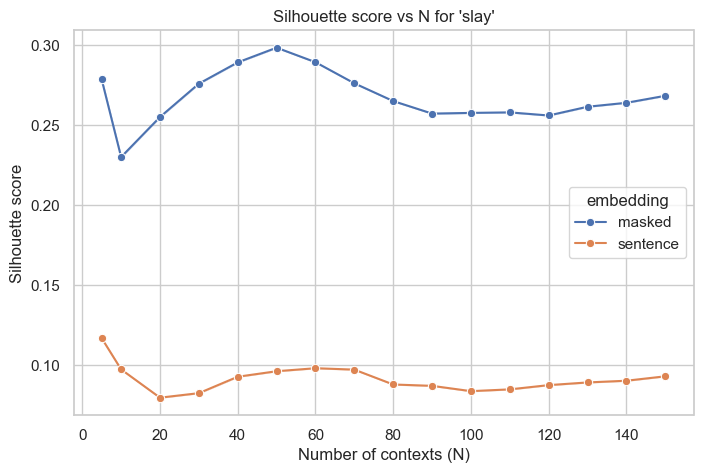

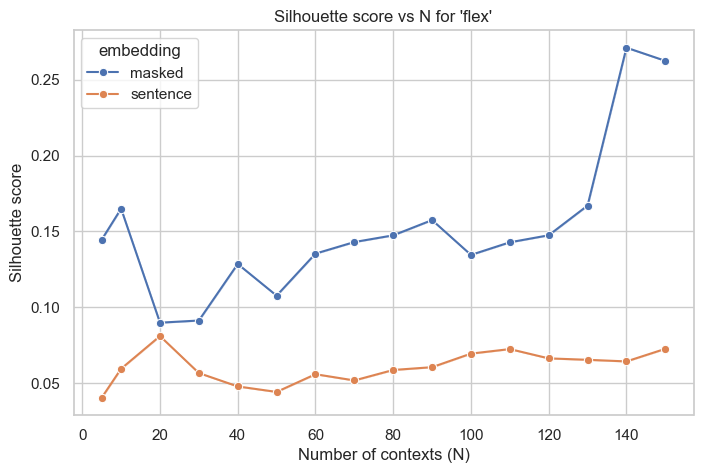

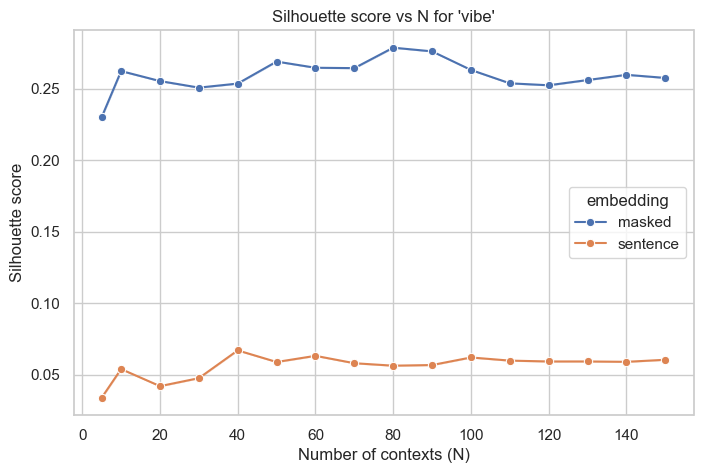

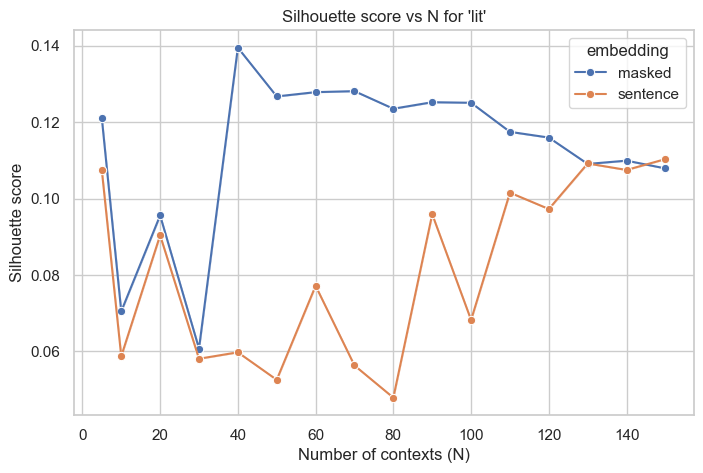

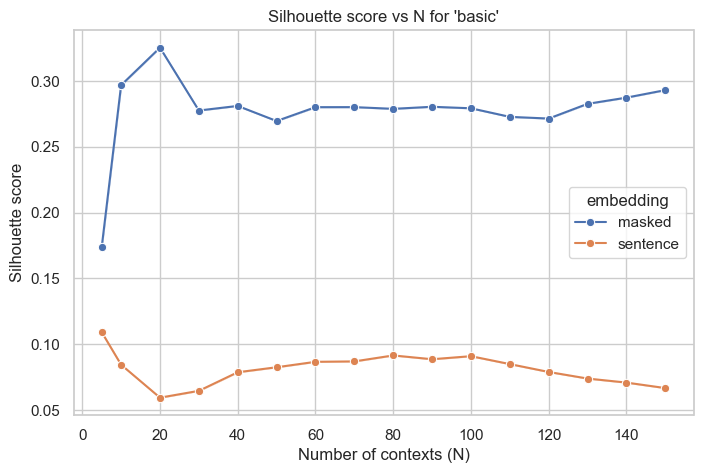

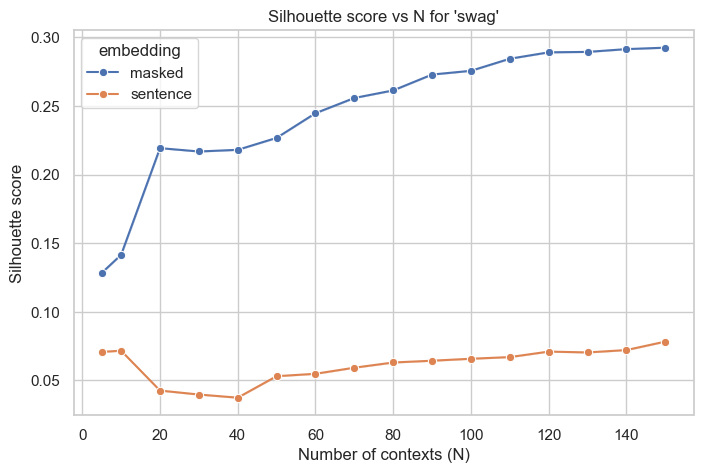

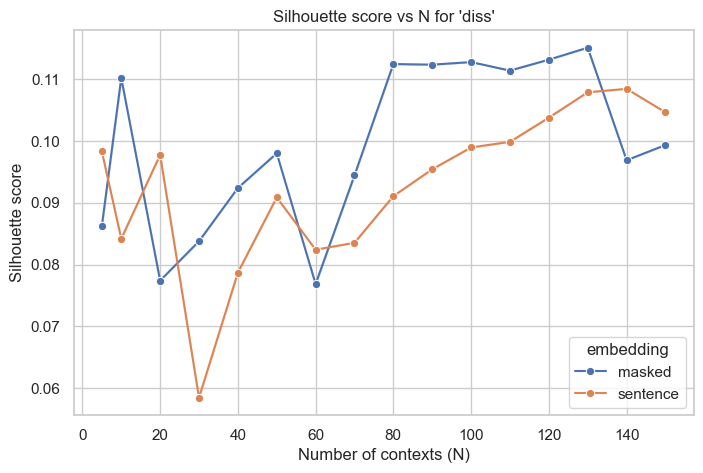

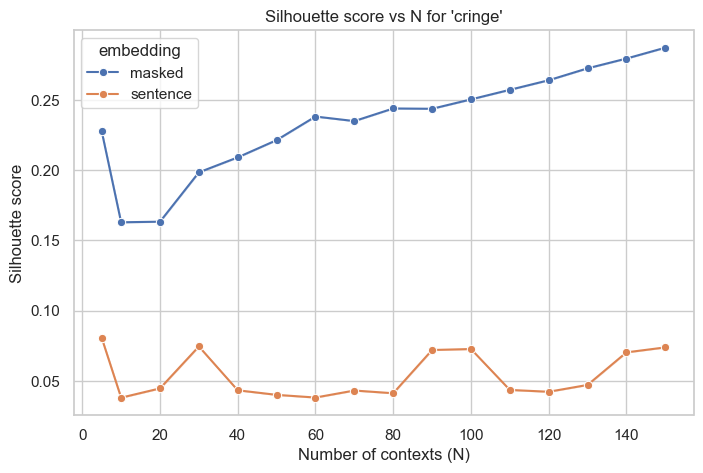

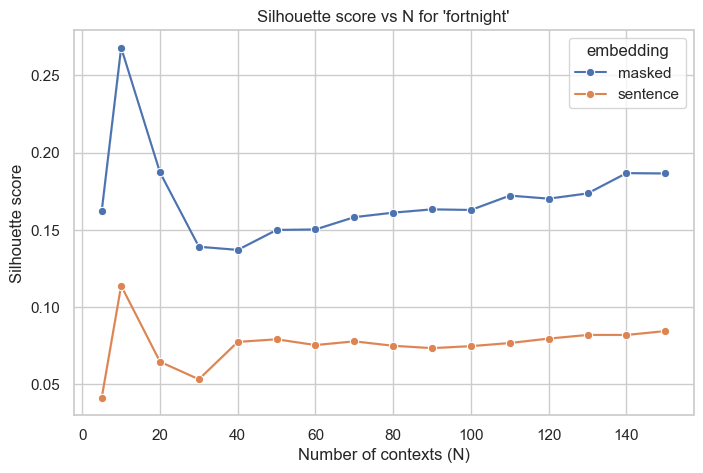

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(12,6))
sns.lineplot(data=df_results, x="N", y="silhouette", hue="embedding", style="term", markers=True)
plt.title("Silhouette score vs Number of contexts (all words)")
plt.xlabel("Number of contexts (N)")
plt.ylabel("Silhouette score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

for term in targets:
    plt.figure(figsize=(8,5))
    df_term = df_results[df_results['term']==term]
    sns.lineplot(data=df_term, x="N", y="silhouette", hue="embedding", marker="o")
    plt.title(f"Silhouette score vs N for '{term}'")
    plt.xlabel("Number of contexts (N)")
    plt.ylabel("Silhouette score")
    plt.show()


In [ ]:
word = "dope"
df_word = df_results[df_results['term']==word]

for idx, row in df_word.iterrows():
    print(f"Term: {row['term']}, Embedding: {row['embedding']}, Cluster: {row['cluster']}, N={row['N']}")
    print(f"Silhouette: {row['silhouette']}")
    if row['decoded_lemmas']:
        print("Decoded centroid:", row['decoded_lemmas'])
    print("Top examples:")
    for ex in row['examples']:
        print(" -", ex)
    print("\n")

Term: dope, Embedding: masked, Cluster: 0, N=5
Silhouette: 0.08907792717218399
Decoded centroid: ['drinking', 'chunk', 'welcoming', 'edges', 'hysterical', 'framed', 'hazy', 'collateral', 'tricky', 'face']
Top examples:
 - That beat is [MASK] honestly
 - Low effort idea but somehow [MASK]
 - This jacket looks [MASK] on you
 - [MASK] energy from the crowd tonight


Term: dope, Embedding: masked, Cluster: 1, N=5
Silhouette: 0.08907792717218399
Decoded centroid: ['inherently', 'framed', 'chunk', 'revolves', 'intentionally', 'さ', 'ん', 'cracked', 'ʐ', 'sy']
Top examples:
 - That beat is [MASK] honestly


Term: dope, Embedding: masked, Cluster: 0, N=10
Silhouette: 0.1251334547996521
Decoded centroid: ['inherently', 'framed', 'chunk', 'revolves', 'intentionally', 'さ', 'ん', 'cracked', 'ʐ', 'sy']
Top examples:
 - That beat is [MASK] honestly


Term: dope, Embedding: masked, Cluster: 1, N=10
Silhouette: 0.1251334547996521
Decoded centroid: ['drinking', 'edges', 'hazy', 'scents', 'brushing', 'welc